# Retina (Neuron) Comparison Notebook

This notebook is altered from the template pipeline notebook, which contains the full code to analyze the performance of an `.h5ad` dataset in terms of its full gene set and lncRNA gene subset.

The data used here is the "snRNA-seq of human retina - all cells" data posted by Li et al. (2026) on the Human Cell Atlas. As it contains both neuron and non-neuron retina cells, the cells populations have been stratified. This notebook contains analysis of the neuron cells.

**Note:** The input data file should be a single-cell RNA-seq dataset in h5ad format, with cell type annotations in the obs dataframe and gene annotations in the var dataframe.

**Note:** If using GitHub for version control and repository sharing, ensure that you add the path to your data folder to the repository's `.gitignore` file, to prevent yourself from exceeding the GitHub's storage limits.

In [34]:
# libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "notebook"
import nsforest as ns
from nsforest import utils
import celltypist as ct

In [35]:
# configs
code_folder = "/Users/vbecker/NSForest-ncRNA/beckersv_neural/retina" # path to the NSForest-ncRNA folder
sys.path.insert(0, os.path.abspath(code_folder))

data_folder = "data/" # path to folder containing the input data file (.h5ad format)
file = data_folder + "data_retina_ds_neuron.h5ad"

output_folder = "output/neuron/"

to_downsample = False # True if you want to downsample the dataset to a specific number of cells, 
                     # False otherwise

to_downsample_n = None # Number of cells to downsample each cluster to, if to_downsample is True

seed = 0 # random seed for reproducibility

## Data Exploration

### Loading AnnData file

In [36]:
adata_raw = sc.read_h5ad(file)
adata_raw

AnnData object with n_obs × n_vars = 494316 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', 

### Looking at sample labels

In [37]:
adata_raw.obs_names # sample names
adata_raw.obs.columns # sample metadata

Index(['reference_genome', 'gene_annotation_version', 'alignment_software',
       'intronic_reads_counted', 'donor_id', 'donor_age',
       'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death',
       'donor_living_at_sample_collection', 'sample_id',
       'sample_preservation_method', 'tissue_ontology_term_id',
       'development_stage_ontology_term_id', 'sample_collection_method',
       'tissue_source', 'tissue_type', 'suspension_derivation_process',
       'suspension_dissociation_reagent', 'suspension_enriched_cell_types',
       'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type',
       'tissue_handling_interval', 'library_id', 'assay_ontology_term_id',
       'sequenced_fragment', 'institute', 'library_id_repository',
       'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id',
       'author_cell_type', 'disease_ontology_term_id', 'reported_diseases',
       'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster',


In [38]:
print(adata_raw.obs["author_cell_type"].value_counts()) # gene counts by cell type

author_cell_type
AII      7589
HAC8     7589
HAC11    7589
HRGC3    7589
HAC13    7589
         ... 
HAC90      79
HAC91      74
HAC92      65
HAC93      55
HAC95      39
Name: count, Length: 119, dtype: int64


### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [39]:
print(adata_raw.var_names) # gene names
print(adata_raw.var.columns) # gene metadata

Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000239945', 'ENSG00000239906', 'ENSG00000241860',
       'ENSG00000241599', 'ENSG00000286448', 'ENSG00000236601',
       'ENSG00000284733',
       ...
       'ENSG00000275249', 'ENSG00000274792', 'ENSG00000274175',
       'ENSG00000275869', 'ENSG00000273554', 'ENSG00000277836',
       'ENSG00000278633', 'ENSG00000276017', 'ENSG00000278817',
       'ENSG00000277196'],
      dtype='object', length=35475)
Index(['feature_is_filtered', 'feature_name', 'feature_reference',
       'feature_biotype', 'feature_length', 'feature_type'],
      dtype='object')


In [40]:
print(adata_raw.var["feature_type"].value_counts()) # gene counts by feature type

feature_type
protein_coding                        19266
lncRNA                                15491
IG_V_pseudogene                         187
IG_V_gene                               146
TR_V_gene                               106
TR_J_gene                                79
IG_D_gene                                37
TR_V_pseudogene                          33
transcribed_unprocessed_pseudogene       29
transcribed_unitary_pseudogene           19
IG_J_gene                                18
artifact                                 17
IG_C_gene                                14
IG_C_pseudogene                           9
TR_C_gene                                 6
TR_J_pseudogene                           4
TR_D_gene                                 4
processed_pseudogene                      3
IG_J_pseudogene                           3
transcribed_processed_pseudogene          2
TEC                                       1
unprocessed_pseudogene                    1
Name: count, dtype:

## Downsampling and Subsetting

### Defining cluster and gene type subset.

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [41]:
cluster_header = "author_cell_type" # column name in adata.obs that contains the cluster labels
subset_col = "feature_type"  # column name in adata.var that contains the gene feature type
subset_gene = "lncRNA"       # feature type to subset the data by (EX: "lncRNA" or "protein_coding")

### Checking cell annotation sizes.

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [42]:
pd.DataFrame(adata_raw.obs[cluster_header].value_counts()).reset_index()

,author_cell_type,count
0,AII,7589
1,HAC8,7589
2,HAC11,7589
3,HRGC3,7589
4,HAC13,7589
...,...,...
114,HAC90,79
115,HAC91,74
116,HAC92,65
117,HAC93,55


### (Optional) Downsampling.

Within this notebook, the data is already downsampled in `retina_script_split.ipynb`. Make edits to downsampling within the aforementioned notebook.

In [43]:
to_downsample = False # should not downsample

if to_downsample:
    adata = ct.samples.downsample_adata(adata_raw, mode = "each", n_cells = to_downsample_n, by = cluster_header,
                                        random_state = seed, return_index = False)
else:
    adata = adata_raw

In [44]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,author_cell_type,count
0,AII,7589
1,HAC8,7589
2,HAC11,7589
3,HRGC3,7589
4,HAC13,7589
...,...,...
114,HAC90,79
115,HAC91,74
116,HAC92,65
117,HAC93,55


In [45]:
# DEBUGGING
print(adata)
print(adata_raw.var["feature_type"].value_counts()) # gene counts by feature type

AnnData object with n_obs × n_vars = 494316 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', 

### Creating gene type subset data.

In [46]:
# keep only lncRNA genes
adata_subset = adata[:, adata.var[subset_col] == subset_gene].copy()

print(adata.shape)
print(adata_subset.shape)

# save
# filename = file.replace(".h5ad", f"neuron_subset_{subset_gene}.h5ad")
# print(f"Saving subset anndata object as...\n{filename}")
# adata_subset.write_h5ad(filename)

(494316, 35475)
(494316, 15491)


## Preprocessing

### Generating scanpy dendrograms

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
output/neuron/dendrogram_author_cell_type_full.png


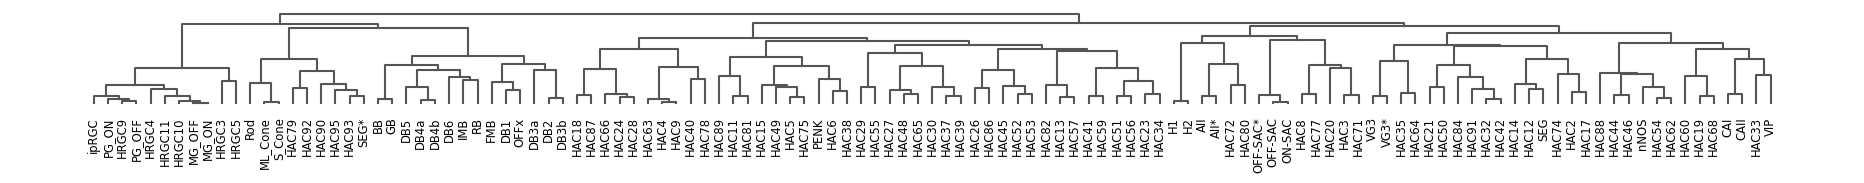

In [47]:
# full adata
if not adata.obsm or "X_pca" not in adata.obsm:
    sc.pp.pca(adata, random_state=seed)

ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = f"{cluster_header}_full")

Saving dendrogram as...
output/neuron/dendrogram_author_cell_type_subset.png


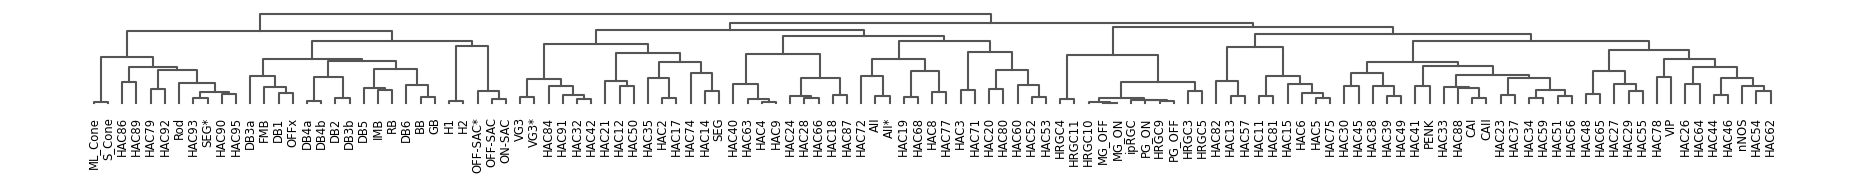

In [48]:
# subset adata
if not adata_subset.obsm or "X_pca" not in adata_subset.obsm:
    sc.pp.pca(adata_subset, random_state=seed)

ns.pp.dendrogram(adata_subset, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix =  f"{cluster_header}_subset")

In [49]:
# DEBUGGING
print(adata.shape)
print(adata_subset.shape)

(494316, 35475)
(494316, 15491)


### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [50]:
# full adata
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 119/119 [02:03<00:00,  1.04s/it]


Saving medians as adata.varm.medians_author_cell_type
median: 0.0
mean: 0.03
std: 0.165
Only positive genes selected. 6747 positive genes out of 35475 total genes
--- 135.47310400009155 seconds ---


,AII,AII*,BB,CAI,CAII,DB1,DB2,DB3a,DB3b,DB4a,...,RB,Rod,SEG,SEG*,S_Cone,VG3,VG3*,VIP,ipRGC,nNOS
ENSG00000188290,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0
ENSG00000131591,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0
ENSG00000078808,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0
ENSG00000131584,0.0,0.303032,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.37893,0.377657,0.0,0.0,0.0
ENSG00000127054,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0


In [51]:
# subset adata
adata_subset = ns.pp.prep_medians(adata_subset, cluster_header)
adata_subset.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 119/119 [00:49<00:00,  2.41it/s]


Saving medians as adata.varm.medians_author_cell_type
median: 0.0
mean: 0.004
std: 0.075
Only positive genes selected. 690 positive genes out of 15491 total genes
--- 50.85191082954407 seconds ---


,AII,AII*,BB,CAI,CAII,DB1,DB2,DB3a,DB3b,DB4a,...,RB,Rod,SEG,SEG*,S_Cone,VG3,VG3*,VIP,ipRGC,nNOS
ENSG00000228526,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
ENSG00000231606,0.0,0.0,0.0,0.000000,0.154118,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.798147,0.0
ENSG00000234593,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.545991,0.0
ENSG00000226526,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
ENSG00000240553,0.0,0.0,0.0,0.230316,0.104935,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [52]:
# full adata
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 119/119 [00:37<00:00,  3.13it/s]

Saving binary scores as adata.varm.binary_scores_author_cell_type
median: 0.0
mean: 0.122
std: 0.252
--- 38.03425979614258 seconds ---


,AII,AII*,BB,CAI,CAII,DB1,DB2,DB3a,DB3b,DB4a,...,RB,Rod,SEG,SEG*,S_Cone,VG3,VG3*,VIP,ipRGC,nNOS
ENSG00000188290,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
ENSG00000131591,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
ENSG00000078808,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
ENSG00000131584,0.0,0.853557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.874879,0.874514,0.0,0.0,0.0
ENSG00000127054,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0


In [53]:
# subset adata
adata_subset = ns.pp.prep_binary_scores(adata_subset, cluster_header)
adata_subset.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 119/119 [00:03<00:00, 30.58it/s]

Saving binary scores as adata.varm.binary_scores_author_cell_type
median: 0.0
mean: 0.083
std: 0.232
--- 3.8983891010284424 seconds ---


,AII,AII*,BB,CAI,CAII,DB1,DB2,DB3a,DB3b,DB4a,...,RB,Rod,SEG,SEG*,S_Cone,VG3,VG3*,VIP,ipRGC,nNOS
ENSG00000228526,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
ENSG00000231606,0.0,0.0,0.0,0.000000,0.830508,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.879772,0.0
ENSG00000234593,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.910422,0.0
ENSG00000226526,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
ENSG00000240553,0.0,0.0,0.0,0.965404,0.949153,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


### Saving preprocessed AnnData as new `.h5ad`.

In [54]:
# full adata
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
data/data_retina_ds_neuron_preprocessed.h5ad


AnnData object with n_obs × n_vars = 494316 × 6747
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', '

In [55]:
# subset adata
filename = file.replace(".h5ad", f"_subset_{subset_gene}_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)
adata_subset

Saving new anndata object as...
data/data_retina_ds_neuron_subset_lncRNA_preprocessed.h5ad


AnnData object with n_obs × n_vars = 494316 × 690
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', 'R

### Visualization of preprocessing steps.

Saving adata.varm[medians_author_cell_type] as histogram as...
output/neuron/histogram_medians_author_cell_type.png


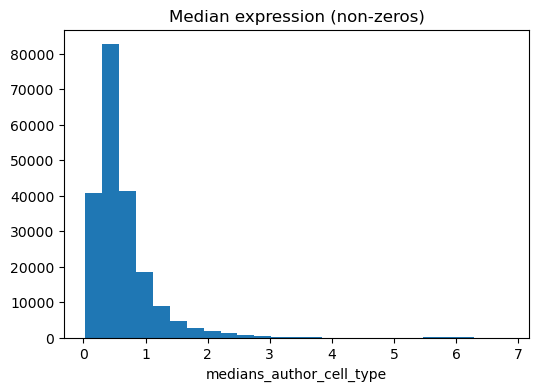

Saving adata.varm[medians_author_cell_type] as histogram as...
output/neuron/histogram_medians_author_cell_type.png


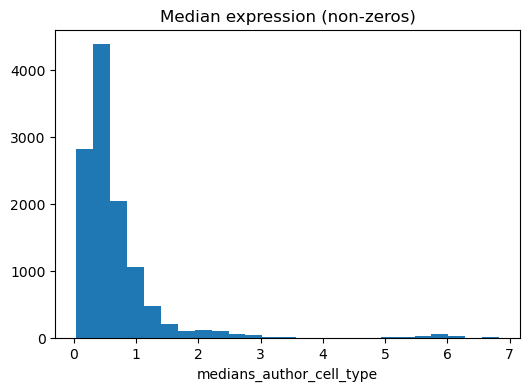

PosixPath('output/neuron/histogram_medians_author_cell_type_subset.png')

In [56]:
# cluster medians (unscaled)
ns.pp.plot_varm(adata, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
Path(output_folder + f"histogram_medians_{cluster_header}.png").rename(
    output_folder + f"histogram_medians_{cluster_header}_full.png"
)

ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
Path(output_folder + f"histogram_medians_{cluster_header}.png").rename(
    output_folder + f"histogram_medians_{cluster_header}_subset.png"
)

Saving adata.varm[medians_author_cell_type] as histogram as...
output/neuron/histogram_medians_author_cell_type.png


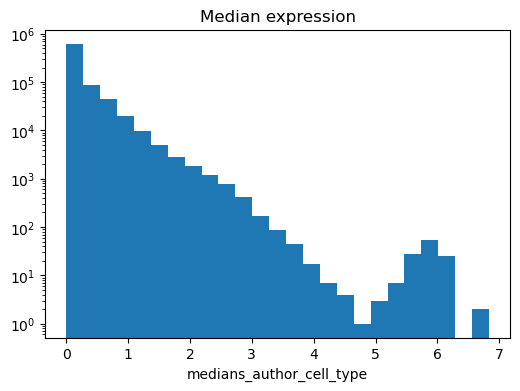

Saving adata.varm[medians_author_cell_type] as histogram as...
output/neuron/histogram_medians_author_cell_type.png


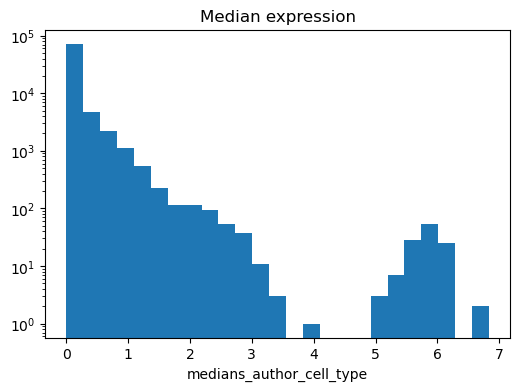

PosixPath('output/neuron/histogram_medians_author_cell_type_subset_log.png')

In [57]:
# cluster medians (log scale)
ns.pp.plot_varm(adata, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
Path(output_folder + f"histogram_medians_{cluster_header}.png").rename(
    output_folder + f"histogram_medians_{cluster_header}_full_log.png"
)

ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
Path(output_folder + f"histogram_medians_{cluster_header}.png").rename(
    output_folder + f"histogram_medians_{cluster_header}_subset_log.png"
)

Saving adata.varm[binary_scores_author_cell_type] as histogram as...
output/neuron/histogram_binary_scores_author_cell_type.png


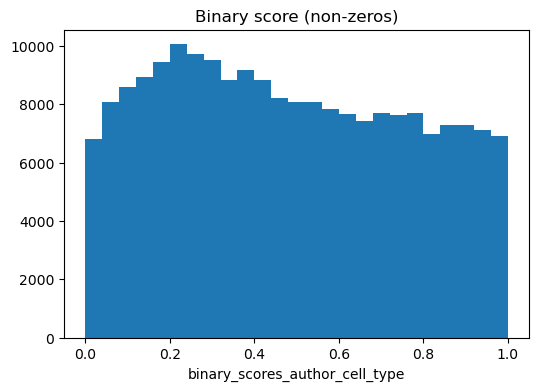

Saving adata.varm[binary_scores_author_cell_type] as histogram as...
output/neuron/histogram_binary_scores_author_cell_type.png


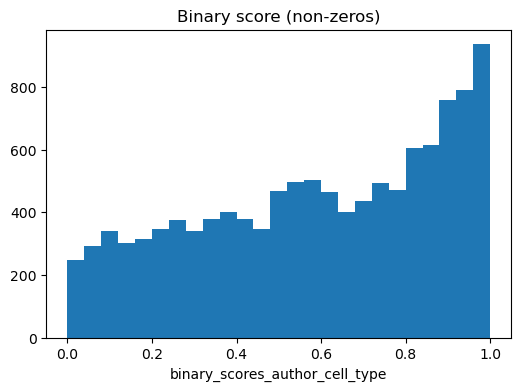

PosixPath('output/neuron/histogram_binary_scores_author_cell_type_subset.png')

In [58]:
# binary scores (unscaled)
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
Path(output_folder + f"histogram_binary_scores_{cluster_header}.png").rename(
    output_folder + f"histogram_binary_scores_{cluster_header}_full.png"
)

ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
Path(output_folder + f"histogram_binary_scores_{cluster_header}.png").rename(
    output_folder + f"histogram_binary_scores_{cluster_header}_subset.png"
)

Saving adata.varm[binary_scores_author_cell_type] as histogram as...
output/neuron/histogram_binary_scores_author_cell_type.png


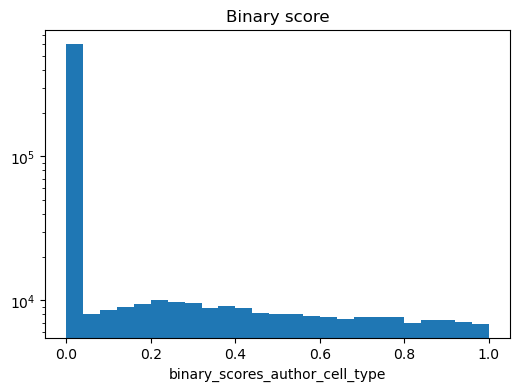

Saving adata.varm[binary_scores_author_cell_type] as histogram as...
output/neuron/histogram_binary_scores_author_cell_type.png


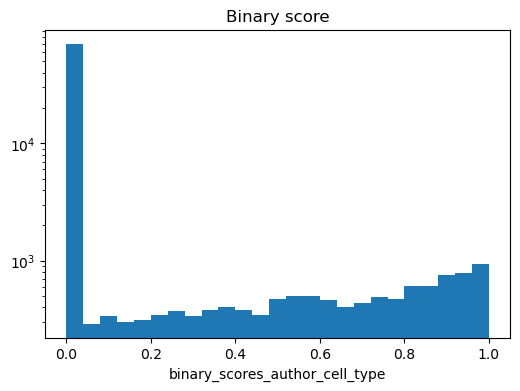

PosixPath('output/neuron/histogram_binary_scores_author_cell_type_subset_log.png')

In [59]:
# binary scores (log scale)
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
Path(output_folder + f"histogram_binary_scores_{cluster_header}.png").rename(
    output_folder + f"histogram_binary_scores_{cluster_header}_full_log.png"
)

ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
Path(output_folder + f"histogram_binary_scores_{cluster_header}.png").rename(
    output_folder + f"histogram_binary_scores_{cluster_header}_subset_log.png"
)

## Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [60]:
# full adata
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
results

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.626
	Average number of genes after gene_selection in each cluster: 576.5210084033613
Saving number of genes selected per cluster as...
output/neuron/author_cell_type_gene_selection.csv
--- 3.929058074951172 seconds ---

Number of clusters to evaluate: 119
1 out of 119:
	AII
	Pre-selected 254 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000113504', 'ENSG00000128536']
	fbeta: 0.763
	precision: 0.916
	recall: 0.457
2 out of 119:
	AII*
	Pre-selected 845 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000113504', 'ENSG00000132915', 'ENSG00000188107']
	fbeta: 0.657
	precision: 0.841
	recall: 0.35
3 out of 119:
	BB
	Pre-selected 183 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000250971', 'ENSG00000113262']
	fbeta: 0.846
	precision: 0.956
	recall: 0.579
4 out of 119:
	CAI
	Pre-sel

KeyboardInterrupt: 

In [ ]:
# subset adata
outputfilename_prefix_subset = cluster_header + "_subset_" + subset_gene
results_subset = ns.nsforesting.NSForest(adata_subset, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)
results_subset

## Visualization of Results

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [ ]:
to_plot = results.copy()
to_plot_subset = results_subset.copy()

In [ ]:
# dendrogram full adata
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# dendrogram subset adata
dendrogram_subset = [] # custom dendrogram order
dendrogram_subset = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].astype("category")
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].cat.set_categories(dendrogram_subset)
to_plot_subset = to_plot_subset.sort_values("clusterName")
to_plot_subset = to_plot_subset.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# marker dictionary full adata
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

# marker dictionary subset adata
markers_dict_subset = dict(zip(to_plot_subset["clusterName"], to_plot_subset["markers"]))
markers_dict_subset

In [ ]:
# dotplot
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.dotplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
# stacked violin plot
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.stackedviolin(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
# heatmap
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.matrixplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

### Plotting classification metrics from NS-Forest results

In [ ]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

### Plotting metrics vs clusterSize

In [ ]:
# f_score
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# precision
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# recall
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
# onTarget
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)